# Varient of 03_LLMs.ipynb with modified model architecture and training arguments.

# Import modules and configs


In [ ]:
import sys

sys.path.append("/mnt/jinho/Development/Projects/2026/BMW_LLMs_finetuning/src")

import json
import math
from datetime import datetime
from pathlib import Path

from datasets import load_dataset
from peft import LoraConfig, get_peft_model
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
)

from utils import retrieve_config

CONFIG_PATH = "/mnt/jinho/Development/Projects/2026/BMW_LLMs_finetuning/config/config.yaml"
CONFIG_DATA = retrieve_config(CONFIG_PATH, "data")
CONFIG_LLMS = retrieve_config(CONFIG_PATH, "llms")
CONFIG_TRAIN = retrieve_config(CONFIG_PATH, "train")

# Define model


In [ ]:
MODEL_NAME = CONFIG_LLMS.get("model", "gpt2-large")
DATA_PATH = f"{CONFIG_DATA.get('db_root', 'database')}/{CONFIG_DATA.get('prepare',{}).get('processed_data_fname', 'articles_proc.jsonl')}"

date_str = datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = Path(f"{CONFIG_DATA.get('output_dir', 'results')}/{date_str}")
if not OUT_DIR.exists():  # Create out_dir folder
    OUT_DIR.mkdir(parents=True, exist_ok=True)

# Load model
model_m1b = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype="auto",
)

# Remove one transformer block (GPT-2 style)
num_layers_before = len(model_m1b.transformer.h)

del model_m1b.transformer.h[-1]  # remove the last block
model_m1b.config.n_layer = len(model_m1b.transformer.h)

print(f"Removed 1 layer: {num_layers_before} -> {len(model_m1b.transformer.h)}")

Removed 1 layer: 12 -> 11


# Fine-tuning methods:

- Full fine tuning
- LoRA

TODO: compare Full fine-tuning vs LoRA

I will choose LoRA method for efficient training

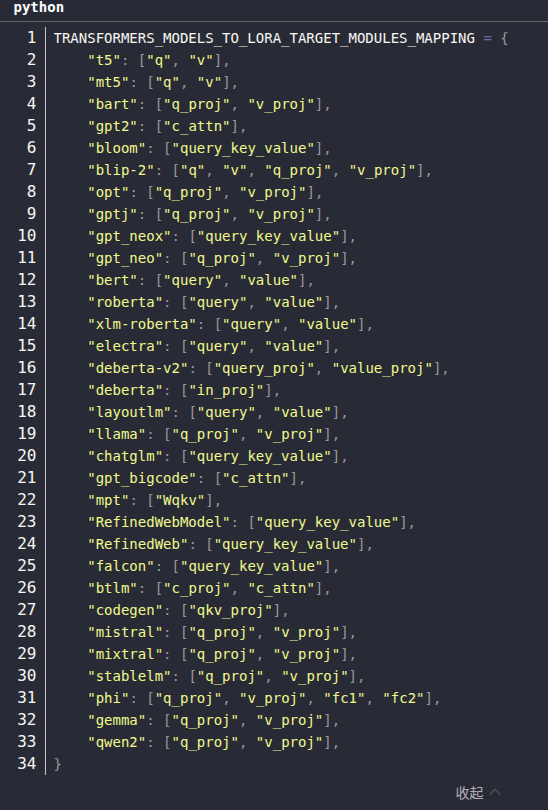

<source: https://blog.csdn.net/u014297502/article/details/140998350>


In [ ]:
print("Parameters for the LoRA method")
print(json.dumps(CONFIG_LLMS.get("LoRA", {}), indent=4))

lora_cfg = LoraConfig(**CONFIG_LLMS.get("LoRA", {}))
model_m1b = get_peft_model(model_m1b, lora_cfg)
model_m1b.print_trainable_parameters()

Parameters for the LoRA method
{
    "r": 8,
    "lora_alpha": 16,
    "lora_dropout": 0.05,
    "bias": "none",
    "task_type": "CAUSAL_LM",
    "target_modules": [
        "c_attn"
    ]
}
trainable params: 270,336 || all params: 117,622,272 || trainable%: 0.2298


/mnt/jinho/Development/conda/envs/bmw_llms/lib/python3.10/site-packages/peft/tuners/lora/layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


For the full model:

```
trainable params: 1,474,560 || all params: 775,504,640 || trainable%: 0.1901
```

For the reduced model:

```
trainable params: 1,433,600 || all params: 755,786,240 || trainable%: 0.1897
```

=> By discarding one layer, the number of parameters is reduced by 19.7M, but the number of trainable parameters is only reduced by 41K. This means that the majority of the parameters are frozen and only a small portion is trainable, which is consistent with the LoRA method.


# Define training data

## Load data


In [ ]:
ds = load_dataset("json", data_files=DATA_PATH)

In [ ]:
# split
ds = ds["train"].train_test_split(test_size=0.1, seed=42)
train_ds, eval_ds = ds["train"], ds["test"]

# Define tokenizer

Sicne gpt2-large model doesn't have a padding token by default, set it to eos_token.

<source: https://medium.com/@prashanth.ramanathan/
fine-tuning-a-pre-trained-gpt-2-model-and-performing-inference-a-hands-on-guide-57c097a3b810>


In [ ]:
def tok(batch):
    return tokenizer(
        batch["x"],
        **CONFIG_LLMS.get("tokenizer", {}),
    )


tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
tokenizer.pad_token = tokenizer.eos_token

train_ds = train_ds.map(tok, batched=True, remove_columns=["x"])
eval_ds = eval_ds.map(tok, batched=True, remove_columns=["x"])

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

/mnt/jinho/Development/conda/envs/bmw_llms/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Map:   0%|          | 0/98 [00:00<?, ? examples/s]

In [ ]:
train_args_cfg = dict(CONFIG_TRAIN)
train_args_cfg["logging_dir"] = str(OUT_DIR / "tb_logs")

args = TrainingArguments(output_dir=str(OUT_DIR), **train_args_cfg)

trainer = Trainer(
    model=model_m1b,
    args=args,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    data_collator=data_collator,
)

In [ ]:
trainer.train()

  0%|          | 0/110 [00:00<?, ?it/s]

{'loss': 4.4572, 'grad_norm': 1.1459754705429077, 'learning_rate': 0.004772727272727273, 'epoch': 0.05}
{'loss': 3.7269, 'grad_norm': 0.5681266188621521, 'learning_rate': 0.004545454545454545, 'epoch': 0.09}
{'loss': 3.7792, 'grad_norm': 0.3368109166622162, 'learning_rate': 0.004318181818181818, 'epoch': 0.14}
{'loss': 3.6009, 'grad_norm': 0.3216569721698761, 'learning_rate': 0.004090909090909091, 'epoch': 0.18}
{'loss': 3.4589, 'grad_norm': 0.5596045255661011, 'learning_rate': 0.003863636363636364, 'epoch': 0.23}
{'loss': 3.498, 'grad_norm': 0.3154295086860657, 'learning_rate': 0.0036363636363636364, 'epoch': 0.27}
{'loss': 3.585, 'grad_norm': 0.42226436734199524, 'learning_rate': 0.003409090909090909, 'epoch': 0.32}
{'loss': 3.3545, 'grad_norm': 0.32225513458251953, 'learning_rate': 0.003181818181818182, 'epoch': 0.36}
{'loss': 3.2968, 'grad_norm': 0.2927059531211853, 'learning_rate': 0.002954545454545455, 'epoch': 0.41}
{'loss': 3.33, 'grad_norm': 0.4016261696815491, 'learning_rate'

  0%|          | 0/98 [00:00<?, ?it/s]

{'eval_loss': 3.0111520290374756, 'eval_runtime': 0.6489, 'eval_samples_per_second': 151.028, 'eval_steps_per_second': 151.028, 'epoch': 0.91}
{'loss': 3.2403, 'grad_norm': 0.2866060137748718, 'learning_rate': 0.00022727272727272727, 'epoch': 0.95}
{'loss': 3.2426, 'grad_norm': 0.2556954026222229, 'learning_rate': 0.0, 'epoch': 1.0}
{'train_runtime': 16.1566, 'train_samples_per_second': 54.591, 'train_steps_per_second': 6.808, 'train_loss': 3.446693706512451, 'epoch': 1.0}


TrainOutput(global_step=110, training_loss=3.446693706512451, metrics={'train_runtime': 16.1566, 'train_samples_per_second': 54.591, 'train_steps_per_second': 6.808, 'total_flos': 194521319981568.0, 'train_loss': 3.446693706512451, 'epoch': 0.9977324263038548})

In [ ]:
# 6) Simple eval: perplexity
eval_out = trainer.evaluate()
ppl = math.exp(eval_out["eval_loss"]) if eval_out.get("eval_loss") else None
print("Eval:", eval_out, "Perplexity:", ppl)

# 7) Save adapters + tokenizer
trainer.save_model(OUT_DIR)
tokenizer.save_pretrained(OUT_DIR)

  0%|          | 0/98 [00:00<?, ?it/s]

Eval: {'eval_loss': 3.0063703060150146, 'eval_runtime': 0.6327, 'eval_samples_per_second': 154.904, 'eval_steps_per_second': 154.904, 'epoch': 0.9977324263038548} Perplexity: 20.2138963502022


('/mnt/jinho/Development/Projects/2026/BMW_LLMs_finetuning/results/20260224_125951/tokenizer_config.json',
 '/mnt/jinho/Development/Projects/2026/BMW_LLMs_finetuning/results/20260224_125951/special_tokens_map.json',
 '/mnt/jinho/Development/Projects/2026/BMW_LLMs_finetuning/results/20260224_125951/vocab.json',
 '/mnt/jinho/Development/Projects/2026/BMW_LLMs_finetuning/results/20260224_125951/merges.txt',
 '/mnt/jinho/Development/Projects/2026/BMW_LLMs_finetuning/results/20260224_125951/added_tokens.json',
 '/mnt/jinho/Development/Projects/2026/BMW_LLMs_finetuning/results/20260224_125951/tokenizer.json')